# **💌 U.S. Logistics Performance Dataset ✧₊˚**
## **Fall 2025 Data Science Project**

#### **Group Members:**  Lexin Deang, Kirsten Fragante, Safiyah Fatima, Jeremy Menecio, Thomas Schlinke  



## **Introduction**
#### **GitHub:** [https://github.com/jerrayhan/320FinalProject](https://github.com/jerrayhan/320FinalProject)  
#### **Dataset:** [Kaggle - U.S. Logistics Performance Dataset](https://www.kaggle.com/datasets/shahriarkabir/us-logistics-performance-dataset)

This dataset was chosen because it provides a wide variety of numerical and categorical features that allow for meaningful analysis of carrier logistics performance across the U.S.   

Our goal is to provide actionable insights for customers and businesses on factors that affect shipping efficiency. Specifically, we want to investigate how carrier choice, shipment cost, and seasonal timing influence transit efficiency. This can help customers make more informed decisions when choosing carriers based on speed, cost, and seasonal performance.

## **Data Preprocessing**

Our project focuses on the dataset found here: [Kaggle - U.S. Logistics Performance Dataset](https://www.kaggle.com/datasets/shahriarkabir/us-logistics-performance-dataset).

This is a simulated dataset containing information on 2,000 U.S. shipment records. It is designed to represent real-world logistics operations, including intentional outliers (3%) and missing values (2%) to mimic data imperfections that commonly occur in real business contexts.  

Each data point represents a single shipment with information about its origin warehouse, destination, carrier, shipment date, delivery date, package weight, cost, delivery status, distance in miles, and transit days.

Before analysis, we aim to, import necessary packages, organize the data into a Pandas Dataframe, and clean the data to prepare it for analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway, pearsonr
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd


df = pd.read_csv('logistics_shipments_dataset.csv')
df

,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days
0,SH10000,Warehouse_MIA,San Francisco,UPS,2023-10-02,2023-10-04,25.7,67.46,Delivered,291,2
1,SH10001,Warehouse_MIA,Atlanta,DHL,2023-12-06,2023-12-09,38.9,268.85,Delivered,1225,3
2,SH10002,Warehouse_LA,Houston,DHL,2023-09-18,2023-09-20,37.2,74.35,Delivered,220,2
3,SH10003,Warehouse_BOS,Seattle,OnTrac,2023-01-26,2023-02-04,42.6,187.04,Delivered,1156,9
4,SH10004,Warehouse_SF,Dallas,OnTrac,2023-06-03,2023-06-06,7.9,120.01,Delivered,1017,3
...,...,...,...,...,...,...,...,...,...,...,...
1995,SH11995,Warehouse_BOS,San Francisco,FedEx,2023-01-18,2023-01-23,7.9,217.78,Delivered,1616,5
1996,SH11996,Warehouse_HOU,Phoenix,UPS,2023-10-27,2023-11-01,36.5,279.47,Delivered,1708,5
1997,SH11997,Warehouse_HOU,Portland,LaserShip,2023-02-13,2023-02-19,11.4,250.32,Delivered,1912,6
1998,SH11998,Warehouse_SEA,Detroit,USPS,2023-10-17,2023-10-22,10.9,272.31,Delivered,2188,5


In [ ]:
# Convert strings to date times
df['Shipment_Date'] = pd.to_datetime(df['Shipment_Date'])
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'])

# Drop missing values
df.dropna(inplace=True)

df.value_counts()

,,,,,,,,,,,count
Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days,
SH11998,Warehouse_SEA,Detroit,USPS,2023-10-17,2023-10-22,10.9,272.31,Delivered,2188,5,1
SH10000,Warehouse_MIA,San Francisco,UPS,2023-10-02,2023-10-04,25.7,67.46,Delivered,291,2,1
SH10001,Warehouse_MIA,Atlanta,DHL,2023-12-06,2023-12-09,38.9,268.85,Delivered,1225,3,1
SH10002,Warehouse_LA,Houston,DHL,2023-09-18,2023-09-20,37.2,74.35,Delivered,220,2,1
SH10003,Warehouse_BOS,Seattle,OnTrac,2023-01-26,2023-02-04,42.6,187.04,Delivered,1156,9,1
...,...,...,...,...,...,...,...,...,...,...,...
SH10012,Warehouse_SEA,New York,FedEx,2023-08-08,2023-08-13,34.4,121.14,Delivered,650,5,1
SH10011,Warehouse_ATL,Boston,Amazon Logistics,2023-05-28,2023-06-04,38.2,357.12,Delayed,2366,6,1
SH10010,Warehouse_MIA,Chicago,FedEx,2023-02-02,2023-02-07,7.1,251.53,Delivered,1736,5,1


The following data cleaning was written with our three hypotheses in mind in order to set the dataset up for smooth statistical testing. We have added necessary columns using information from other columns for our hypothesis tests and removed related outliers.

In [ ]:
# Changes statuses to only two possible outcomes: 'Delivered' or 'Not Delivered' (replaced 'Lost', 'Delayed', 'In Transit')
df['Status'] = df['Status'].apply(lambda x: 'Delivered' if x=='Delivered' else 'Not Delivered')

# Transit distance per day
df['Transit_Distance_per_Day'] = df['Distance_miles']/df['Transit_Days']

# Remove cost outliers
df = df[(df['Cost'] < df['Cost'].quantile(0.99)) &
              (df['Transit_Distance_per_Day'] < df['Transit_Distance_per_Day'].quantile(0.99))]

# Extracts the season and adds it based on SHIPMENT DAY
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Shipment_Date'].apply(get_season)

df


/tmp/ipython-input-3965137584.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Season'] = df['Shipment_Date'].apply(get_season)


,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days,Transit_Distance_per_Day,Season
0,SH10000,Warehouse_MIA,San Francisco,UPS,2023-10-02,2023-10-04,25.7,67.46,Delivered,291,2,145.500000,Fall
1,SH10001,Warehouse_MIA,Atlanta,DHL,2023-12-06,2023-12-09,38.9,268.85,Delivered,1225,3,408.333333,Winter
2,SH10002,Warehouse_LA,Houston,DHL,2023-09-18,2023-09-20,37.2,74.35,Delivered,220,2,110.000000,Fall
3,SH10003,Warehouse_BOS,Seattle,OnTrac,2023-01-26,2023-02-04,42.6,187.04,Delivered,1156,9,128.444444,Winter
4,SH10004,Warehouse_SF,Dallas,OnTrac,2023-06-03,2023-06-06,7.9,120.01,Delivered,1017,3,339.000000,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,SH11994,Warehouse_SF,Seattle,Amazon Logistics,2023-11-10,2023-11-12,59.7,130.00,Delivered,237,2,118.500000,Fall
1995,SH11995,Warehouse_BOS,San Francisco,FedEx,2023-01-18,2023-01-23,7.9,217.78,Delivered,1616,5,323.200000,Winter
1996,SH11996,Warehouse_HOU,Phoenix,UPS,2023-10-27,2023-11-01,36.5,279.47,Delivered,1708,5,341.600000,Fall
1997,SH11997,Warehouse_HOU,Portland,LaserShip,2023-02-13,2023-02-19,11.4,250.32,Delivered,1912,6,318.666667,Winter


## **Exploratory Data Analysis**

#### **Overview of the Dataset**

`df.info()` describes our main characteristics and relevant columns. We dropped cost outliers earlier so we can improve our model's performance when comparing carrier services with cost, where we may later apply regression. Our main features include Status, Transit_Distance_Per_Day, and cost.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1888 entries, 0 to 1998
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Shipment_ID               1888 non-null   object        
 1   Origin_Warehouse          1888 non-null   object        
 2   Destination               1888 non-null   object        
 3   Carrier                   1888 non-null   object        
 4   Shipment_Date             1888 non-null   datetime64[ns]
 5   Delivery_Date             1888 non-null   datetime64[ns]
 6   Weight_kg                 1888 non-null   float64       
 7   Cost                      1888 non-null   float64       
 8   Status                    1888 non-null   object        
 9   Distance_miles            1888 non-null   int64         
 10  Transit_Days              1888 non-null   int64         
 11  Transit_Distance_per_Day  1888 non-null   float64       
 12  Season                   

In [ ]:
summerC = df['Season'].value_counts()['Summer']
fallC = df['Season'].value_counts()['Fall']
winterC = df['Season'].value_counts()['Winter']
springC = df['Season'].value_counts()['Spring']
print("Shipments by season for \n Summer:", summerC, "\n Fall:", fallC, "\n Winter:", winterC, "\n Spring:", springC, "\n")

Shipments by season for 
 Summer: 481 
 Fall: 482 
 Winter: 447 
 Spring: 478 



In [ ]:
df.describe()

,Shipment_Date,Delivery_Date,Weight_kg,Cost,Distance_miles,Transit_Days,Transit_Distance_per_Day
count,1888,1888,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000
mean,2023-07-04 07:24:39.661016832,2023-07-08 22:52:52.881356032,30.101324,196.303639,1273.756356,4.197034,299.915000
min,2023-01-01 00:00:00,2023-01-03 00:00:00,0.000000,17.890000,101.000000,1.000000,26.250000
25%,2023-04-04 18:00:00,2023-04-10 00:00:00,12.375000,117.575000,693.750000,3.000000,224.150000
50%,2023-07-05 00:00:00,2023-07-10 00:00:00,20.600000,196.325000,1268.500000,4.000000,313.666667
75%,2023-10-03 06:00:00,2023-10-07 00:00:00,33.600000,271.242500,1859.000000,5.000000,380.062500
max,2023-12-31 00:00:00,2024-01-12 00:00:00,5404.200000,416.420000,2499.000000,12.000000,510.000000
std,NaN,NaN,128.443636,93.381891,687.475556,1.817990,108.961811


In [ ]:
print("Rows, Columns:", df.shape)
print("Columns", list(df.columns))

Rows, Columns: (1888, 13)
Columns ['Shipment_ID', 'Origin_Warehouse', 'Destination', 'Carrier', 'Shipment_Date', 'Delivery_Date', 'Weight_kg', 'Cost', 'Status', 'Distance_miles', 'Transit_Days', 'Transit_Distance_per_Day', 'Season']


Above we printed some information about our dataset, notably the average, max, and min values for each of the categories, as well as the count for shipments by season. Since the dataset covers logistics operations for large scale shipments, it makes sense that the data we see for the Cost is high.

Another thing to observe is the fact that there were fewer shipments during winter.

#### **Hypothesis 1:**

For our first hypothesis, we wanted to test the reliability between the different carriers. We will compare two categorical variables, the carrier & status through use of a Chi-Square test.


> Null (H0): Carrier and delivery success rate are independent (success rate is equal across carriers).

> Alternative (HA): Carrier and delivery success rate are not independent (some carriers are more successful than others).

In [ ]:
# code for chi square test
contingency = pd.crosstab(df['Carrier'], df['Status'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-Square Stat: {chi2}, p-val: {p}")

Chi-Square Stat: 5.151562479377576, p-val: 0.5245264118707864


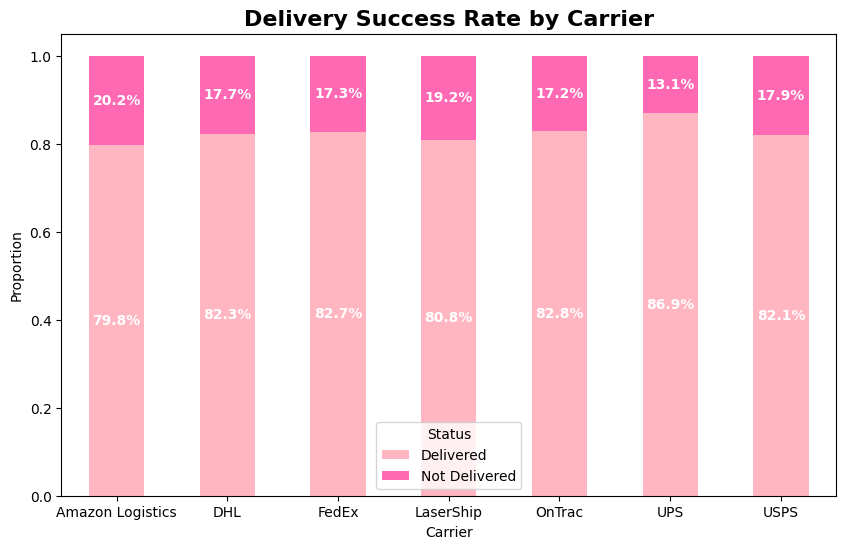

In [ ]:
# code for graph (stacked bar graph)
contingency_norm = contingency.div(contingency.sum(axis=1), axis=0)

colors = ['#FFB6C1', '#FF69B4']
ax = contingency_norm.plot(kind='bar', stacked=True, figsize=(10,6), color=colors)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width/2, y + height/2, f"{height*100:.1f}%", ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.ylabel("Proportion")
plt.xlabel("Carrier")
plt.title("Delivery Success Rate by Carrier", fontsize=16, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='Status', labels=['Delivered', 'Not Delivered'])

plt.show()

**Hypothesis 1 Conclusion**

Using a significance level of **alpha = 0.05**, our chi-square test of independence has resulted in a p-value of **p=0.52452**, so we **fail to reject** the null hypothesis. Additionally, there is a chi-square stat of **5**, which falls on the lower end indicating a smaller difference between observed data.

This means that there is no statistical evidence that delivery success rate depends on the carrier. In other words, all carriers appear to have similar delivery reliability in this dataset. This is evident in our graph above, where it seems that the bars are around the same level for each carrier.

Even though we have not found a significant difference between carriers in terms of success, we can further explore how different factors such as cost and seasons affect performance. This is shown in the next two hypothesis.

### **Hypothesis 2:**

To further investigate if cost per shipment is related to transit efficiency, we use a pearson correlation and scatter plot to visualize and test if higher cost shipments move faster.

> Null (H0): Cost per shipment is unrelated to transit efficiency (distance per day).

> Alternative (HA): Higher-cost shipments are faster (higher transit distance per day).

In [ ]:
# code for pearson correlation
r, p = pearsonr(df['Cost'], df['Transit_Distance_per_Day'])
print(f"Pearson Correlation: {r:.3f}, p-value: {p}")

Pearson Correlation: 0.606, p-value: 1.059844600490084e-189


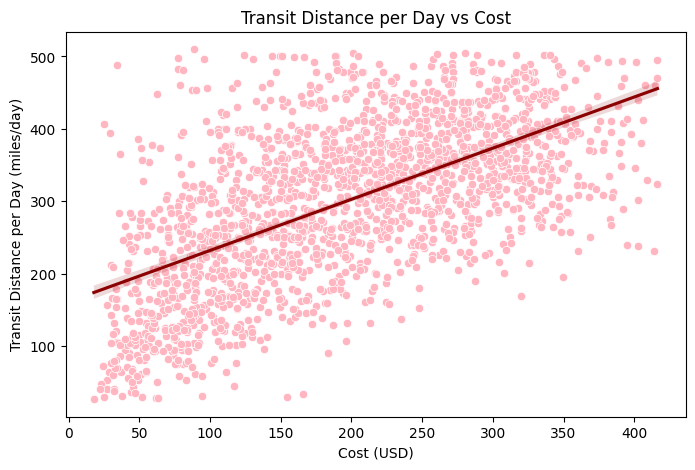

In [ ]:
# code for graph
plt.figure(figsize=(8,5))
sns.scatterplot(x='Cost', y='Transit_Distance_per_Day', data=df, color='#ffb6c1')
sns.regplot(x='Cost', y='Transit_Distance_per_Day', data=df, scatter=False, color='darkred')
plt.title("Transit Distance per Day vs Cost")
plt.xlabel("Cost (USD)")
plt.ylabel("Transit Distance per Day (miles/day)")
plt.show()

**Conclusion for Hypothesis 2:**

Using a significance level of **alpha = 0.05**, our pearson correlation test has resulted in a p-value of **p = 1.059844600490084e-189**, so we **reject** the null hypothesis.

This shows a strong positive relationship between shipment cost and transit efficiency. In other words, more expensive shipments tend to move faster, which aligns with the intuition that a faster delivery can be induced by paying more.

#### **Hypothesis 3:**

To investigate carrier performance, we analyze their performance across season and check over their transit efficiency. Since we compare many groups (carriers), we use a Two-way ANOVA test as well as Tukey Post-Hoc. Through the post-hoc, we get to look at localized differences between carrier and season.

> Null (H0): Carrier performance does not depend on the season (transit efficiency is consistent throughout the year).

> Alternative (HA): Carrier performance depends on the season.

In [ ]:
# code for two-way anova
model = ols('Transit_Distance_per_Day ~ C(Carrier) + C(Season) + C(Carrier):C(Season)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                            sum_sq      df         F    PR(>F)
C(Carrier)            2.280385e+04     6.0  0.319337  0.927163
C(Season)             4.536119e+04     3.0  1.270446  0.282903
C(Carrier):C(Season)  1.979076e+05    18.0  0.923811  0.548959
Residual              2.213706e+07  1860.0       NaN       NaN


In [ ]:
# code for post-hoc
df['Carrier_Season'] = df['Carrier'] + '_' + df['Season']

tukey = pairwise_tukeyhsd(endog=df['Transit_Distance_per_Day'],
                          groups=df['Carrier_Season'],
                          alpha=0.05)
print(tukey)

/tmp/ipython-input-193268718.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Carrier_Season'] = df['Carrier'] + '_' + df['Season']


                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                  group2         meandiff p-adj    lower    upper   reject
-----------------------------------------------------------------------------------------
  Amazon Logistics_Fall Amazon Logistics_Spring  19.0746    1.0  -50.7914  88.9406  False
  Amazon Logistics_Fall Amazon Logistics_Summer  34.7891 0.9908  -35.8969  105.475  False
  Amazon Logistics_Fall Amazon Logistics_Winter -24.4477    1.0  -95.4221  46.5267  False
  Amazon Logistics_Fall                DHL_Fall  13.6421    1.0  -57.6288  84.9129  False
  Amazon Logistics_Fall              DHL_Spring  -6.3436    1.0  -75.9503  63.2632  False
  Amazon Logistics_Fall              DHL_Summer   8.5838    1.0  -58.9584   76.126  False
  Amazon Logistics_Fall              DHL_Winter  15.5148    1.0  -57.0302  88.0598  False
  Amazon Logistics_Fall              FedEx_Fall   3.5253    1.0  -64.8792  71.9297  False
  Amazon L

<Figure size 1000x600 with 0 Axes>

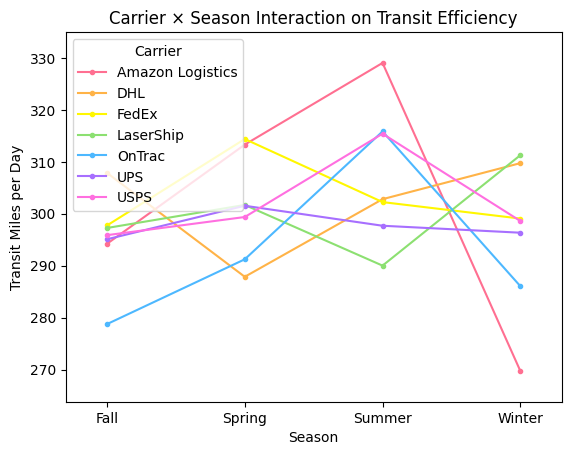

In [ ]:
# code for graph
from statsmodels.graphics.factorplots import interaction_plot
plt.figure(figsize=(10,6))
interaction_plot(df['Season'], df['Carrier'], df['Transit_Distance_per_Day'], colors=['#FF6F91', '#FFB347', '#FFF700', '#8CE071', '#4DB8FF', '#A76FFF', '#FF6FE0'])
plt.ylabel("Transit Miles per Day")
plt.title("Carrier × Season Interaction on Transit Efficiency")
plt.show()

**Conclusion for Hypothesis 3**

Using a significance level of **alpha = 0.05**, our two-way ANOVA test has resulted in p-values of **{Carrier: p = 0.927; Season: p = 0.283; Carrier x Season: p = 0.549}**, so we **fail to reject** the null hypothesis for all three categories.

This means that, statistically, there is no significant evidence that season affects transit efficiency across all carriers. However, visually looking at the graph we can notice that certain carriers, such as Amazon and OnTrac, tend to do much better in the summer than the winter, though the difference is neglible enough to not be statistically significant. Thought we failed to reject our null, the graph can still serve as a useful tool for noticing discrepancies across carrier performance based on season.

## **Insights and Conclusions**

The `Exploratory Data Analysis` section of this report aimed to break down the U.S logistics performance and analyze the dataset and highlight any relationships and patterns that have the potential to derive useful insights that can contribue to logistics decisions and strategies that pertain to carrier instances.

### Insights

1. **Carrier Reliability**
  *   By a `Chi-Square Test`, it was determined that the differences were leveled and insignificant being over the alpha value (p > 0.05) throughout the different delivery success rates across the various carriers within the dataset.
  *   The insignificant differences between the carriers suggest that delivery success rates do not depend on the carrier used. This means that whichever carrier is used by any individual does not statistically impose an impact on its delivery success.

2.   **Shipment Cost and Speed**

*   By a `Correlation analysis`, (Pearson r = .606, p < 0.05) there is an indicated strong positive relationship between the cost of shipment and its delivery speed.
*   This means that shipments that fall within the higher cost side will almost always be delivered faster than shipments that cost significantly less.

3.   **Seasonal Effects**


*   Statistically, by a `Two-Way ANOVA` test there was no significance between carriers (p = 0.927), seasons (p = 0.283), as well as the interaction between carriers & seasons (p = 0.549) which indicated consistency with performance across seasons.
*   Although, given the graph, we can visually attest to a shift in shipments decreasing for a particular carrier (Amazon) when approaching the winter.









## Machine Learning Analysis